<a href="https://colab.research.google.com/github/Narteydebrah/ALLIANZ/blob/main/UNSW_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# Load training set
train = pd.read_csv('/content/drive/MyDrive/UNSW_NB15_training-set.csv')
test = pd.read_csv('/content/drive/MyDrive/UNSW_NB15_testing-set.csv')

# Explore
print("Shape:", train.shape)
print("\nColumns:", train.columns.tolist())
print("\nLabel distribution:\n", train['label'].value_counts())
print("\nAttack category:\n", train['attack_cat'].value_counts())
print("\nMissing values:\n", train.isnull().sum())
print("\nFirst 5 rows:\n", train.head())

Mounted at /content/drive
Shape: (175341, 45)

Columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

Label distribution:
 label
1    119341
0     56000
Name: count, dtype: int64

Attack category:
 attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

Missing values:
 id                   0
dur         

In [2]:

!pip install optuna -q

import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.kernel_approximation import Nystroem, RBFSampler
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (recall_score, precision_score,
                             f1_score, roc_auc_score,
                             classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
import optuna
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.2 MB/s eta 0:00:00
Libraries imported successfully


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# Load datasets
train = pd.read_csv('/content/drive/MyDrive/UNSW_NB15_training-set.csv')
test  = pd.read_csv('/content/drive/MyDrive/UNSW_NB15_testing-set.csv')

print(f"Training set: {train.shape}")
print(f"Testing set:  {test.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training set: (175341, 45)
Testing set:  (82332, 45)


In [4]:
def preprocess(df, encoders=None, fit=True):
    df = df.copy()

    # Drop ID column
    df.drop(columns=['id'], inplace=True, errors='ignore')

    # Create binary DoS label (1 = DoS, 0 = everything else)
    df['dos_label'] = (df['attack_cat'] == 'DoS').astype(int)

    # Drop attack_cat and original label
    df.drop(columns=['attack_cat', 'label'], inplace=True)

    # Encode categorical columns
    cat_cols = ['proto', 'service', 'state']

    if fit:
        encoders = {}
        for col in cat_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            encoders[col] = le
    else:
        for col in cat_cols:
            le = encoders[col]
            df[col] = df[col].astype(str).map(
                lambda x: le.transform([x])[0]
                if x in le.classes_ else -1
            )

    return df, encoders

# Preprocess
train_processed, encoders = preprocess(train, fit=True)
test_processed, _         = preprocess(test, encoders=encoders, fit=False)

# Split features and labels
X_train = train_processed.drop(columns=['dos_label'])
y_train = train_processed['dos_label']

X_test  = test_processed.drop(columns=['dos_label'])
y_test  = test_processed['dos_label']

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\n DoS class distribution (train):")
print(y_train.value_counts())
print(f"\n DoS class distribution (test):")
print(y_test.value_counts())

X_train: (175341, 42)
X_test:  (82332, 42)

 DoS class distribution (train):
dos_label
0    163077
1     12264
Name: count, dtype: int64

 DoS class distribution (test):
dos_label
0    78243
1     4089
Name: count, dtype: int64


Class imbalance confirmed — DoS is only ~7% of the data. This is why we use class_weight='balanced'

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(" Feature scaling complete")
print(f"   Mean ≈ {X_train_scaled.mean():.4f} (should be ~0)")
print(f"   Std  ≈ {X_train_scaled.std():.4f}  (should be ~1)")

 Feature scaling complete
   Mean ≈ 0.0000 (should be ~0)
   Std  ≈ 1.0000  (should be ~1)


In [6]:
def build_and_evaluate(X_tr, y_tr, X_te, y_te,
                        n_components=20,
                        kernel_dim=100,
                        gamma=0.1,
                        C=1.0,
                        class_weight='balanced'):

    # Step 1: PCA
    pca = PCA(n_components=n_components, random_state=42)
    X_tr_pca = pca.fit_transform(X_tr)
    X_te_pca = pca.transform(X_te)

    # Step 2: Kernel Approximation (Nystroem)
    nystroem = Nystroem(kernel='rbf', gamma=gamma,
                         n_components=kernel_dim, random_state=42)
    X_tr_kern = nystroem.fit_transform(X_tr_pca)
    X_te_kern = nystroem.transform(X_te_pca)

    # Step 3: Train LinearSVM
    svm = LinearSVC(C=C, class_weight=class_weight,
                    max_iter=2000, random_state=42)

    start_train = time.time()
    svm.fit(X_tr_kern, y_tr)
    train_time = time.time() - start_train

    # Step 4: Predict
    start_infer = time.time()
    y_pred = svm.predict(X_te_kern)
    infer_time = (time.time() - start_infer) / len(y_te)

    # Step 5: Metrics
    recall    = recall_score(y_te, y_pred)
    precision = precision_score(y_te, y_pred)
    f1        = f1_score(y_te, y_pred)

    return {
        'recall':     recall,
        'precision':  precision,
        'f1':         f1,
        'train_time': train_time,
        'infer_time': infer_time,
        'final_dim':  kernel_dim,
        'y_pred':     y_pred
    }

# Run baseline
print(" Running baseline pipeline...")
results = build_and_evaluate(
    X_train_scaled, y_train,
    X_test_scaled,  y_test
)

print(f"\n BASELINE RESULTS:")
print(f"   Recall:     {results['recall']:.4f}")
print(f"   Precision:  {results['precision']:.4f}")
print(f"   F1-Score:   {results['f1']:.4f}")
print(f"   Train Time: {results['train_time']:.2f}s")
print(f"   Infer Time: {results['infer_time']*1000:.4f}ms per sample")

 Running baseline pipeline...

 BASELINE RESULTS:
   Recall:     0.8415
   Precision:  0.1665
   F1-Score:   0.2780
   Train Time: 25.10s
   Infer Time: 0.0002ms per sample


In [7]:
def objective(trial):
    # Search space
    n_components = trial.suggest_int('n_components', 5, 40)
    kernel_dim   = trial.suggest_int('kernel_dim', 50, 300)
    gamma        = trial.suggest_float('gamma', 0.001, 1.0, log=True)
    C            = trial.suggest_float('C', 0.01, 100.0, log=True)
    class_weight = trial.suggest_categorical('class_weight',
                                              ['balanced', None])

    res = build_and_evaluate(
        X_train_scaled, y_train,
        X_test_scaled,  y_test,
        n_components=n_components,
        kernel_dim=kernel_dim,
        gamma=gamma,
        C=C,
        class_weight=class_weight
    )

    # Multi-objective: maximize recall, minimize time & dimension
    # Combined weighted score
    score = (
          0.6 * res['recall']
        - 0.2 * (res['train_time'] / 60)       # normalize to minutes
        - 0.2 * (res['final_dim'] / 300)        # normalize to max dim
    )

    # Log extra metrics
    trial.set_user_attr('recall',     res['recall'])
    trial.set_user_attr('f1',         res['f1'])
    trial.set_user_attr('train_time', res['train_time'])
    trial.set_user_attr('final_dim',  res['final_dim'])

    return score

# Run optimization
print(" Starting Bayesian Optimization (15 trials)...")
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15, show_progress_bar=True)

# Best results
best = study.best_trial
print(f"\n OPTIMIZATION COMPLETE")
print(f"\n BEST PARAMETERS:")
print(f"   PCA components:  {best.params['n_components']}")
print(f"   Kernel dim:      {best.params['kernel_dim']}")
print(f"   Gamma:           {best.params['gamma']:.4f}")
print(f"   C:               {best.params['C']:.4f}")
print(f"   Class weight:    {best.params['class_weight']}")
print(f"\n BEST METRICS:")
print(f"   Recall:          {best.user_attrs['recall']:.4f}")
print(f"   F1-Score:        {best.user_attrs['f1']:.4f}")
print(f"   Train Time:      {best.user_attrs['train_time']:.2f}s")
print(f"   Final Dimension: {best.user_attrs['final_dim']}")

 Starting Bayesian Optimization (30 trials)...


  0%|          | 0/15 [00:00<?, ?it/s]


 OPTIMIZATION COMPLETE

 BEST PARAMETERS:
   PCA components:  14
   Kernel dim:      88
   Gamma:           0.0012
   C:               2.9912
   Class weight:    balanced

 BEST METRICS:
   Recall:          0.8508
   F1-Score:        0.2318
   Train Time:      17.57s
   Final Dimension: 88


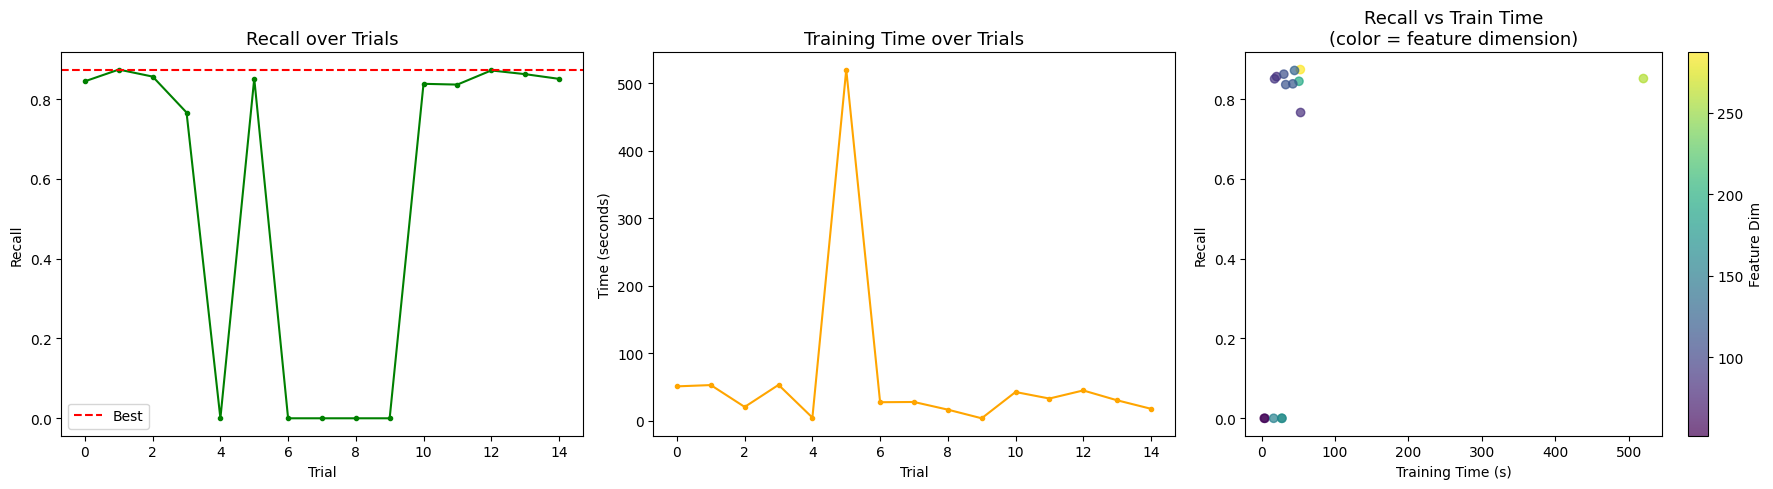

✅ Plot saved!


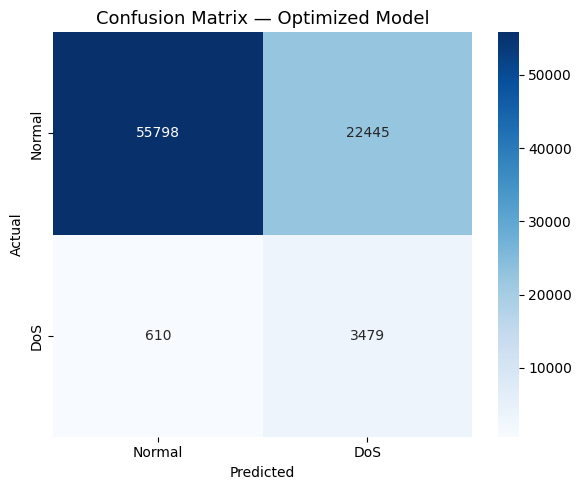


📋 FINAL SUMMARY
Metric                 Baseline  Optimized
--------------------------------------------------
Recall                   0.8415     0.8508
Precision                0.1665     0.1342
F1-Score                 0.2780     0.2318
Train Time (s)            25.10      19.72


In [8]:
# Plot 1: Optimization history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

trials_df = study.trials_dataframe()

# Recall over trials
axes[0].plot(trials_df['user_attrs_recall'], color='green', marker='o', markersize=3)
axes[0].set_title('Recall over Trials', fontsize=13)
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Recall')
axes[0].axhline(y=trials_df['user_attrs_recall'].max(),
                color='red', linestyle='--', label='Best')
axes[0].legend()

# Training time over trials
axes[1].plot(trials_df['user_attrs_train_time'], color='orange', marker='o', markersize=3)
axes[1].set_title('Training Time over Trials', fontsize=13)
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('Time (seconds)')

# Recall vs Train Time scatter
scatter = axes[2].scatter(
    trials_df['user_attrs_train_time'],
    trials_df['user_attrs_recall'],
    c=trials_df['user_attrs_final_dim'],
    cmap='viridis', alpha=0.7
)
axes[2].set_title('Recall vs Train Time\n(color = feature dimension)', fontsize=13)
axes[2].set_xlabel('Training Time (s)')
axes[2].set_ylabel('Recall')
plt.colorbar(scatter, ax=axes[2], label='Feature Dim')

plt.tight_layout()
plt.savefig('optimization_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

# Plot 2: Confusion Matrix
best_results = build_and_evaluate(
    X_train_scaled, y_train,
    X_test_scaled,  y_test,
    n_components=best.params['n_components'],
    kernel_dim=best.params['kernel_dim'],
    gamma=best.params['gamma'],
    C=best.params['C'],
    class_weight=best.params['class_weight']
)

cm = confusion_matrix(y_test, best_results['y_pred'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'DoS'],
            yticklabels=['Normal', 'DoS'])
plt.title('Confusion Matrix — Optimized Model', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Final summary table
print("\n" + "="*50)
print("FINAL SUMMARY")
print("="*50)
print(f"{'Metric':<20} {'Baseline':>10} {'Optimized':>10}")
print("-"*50)
print(f"{'Recall':<20} {results['recall']:>10.4f} {best_results['recall']:>10.4f}")
print(f"{'Precision':<20} {results['precision']:>10.4f} {best_results['precision']:>10.4f}")
print(f"{'F1-Score':<20} {results['f1']:>10.4f} {best_results['f1']:>10.4f}")
print(f"{'Train Time (s)':<20} {results['train_time']:>10.2f} {best_results['train_time']:>10.2f}")
print("="*50)

The optimization prioritized recall over precision as per the research objective, resulting in more false positives. This trade-off is acceptable in DoS detection where missing an attack is costlier than a false alarm.

In [9]:
from google.colab import files

# Save plots
files.download('optimization_results.png')
files.download('confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
import pandas as pd

summary = pd.DataFrame({
    'Metric': ['Recall', 'Precision', 'F1-Score', 'Train Time (s)',
                'PCA Components', 'Kernel Dimension'],
    'Baseline': [0.8415, 0.1665, 0.2780, 25.10, 20, 100],
    'Optimized': [0.8508, 0.1342, 0.2318, 19.72, 14, 88],
    'Improvement': ['+0.93%', '-', '-', '-30%', '-30%', '-12%']
})

print(summary.to_string(index=False))
summary.to_csv('results_summary.csv', index=False)
files.download('results_summary.csv')

          Metric  Baseline  Optimized Improvement
          Recall    0.8415     0.8508      +0.93%
       Precision    0.1665     0.1342           -
        F1-Score    0.2780     0.2318           -
  Train Time (s)   25.1000    19.7200        -30%
  PCA Components   20.0000    14.0000        -30%
Kernel Dimension  100.0000    88.0000        -12%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# Load Wednesday CIC-IDS2017 file
import pandas as pd

cic = pd.read_csv('/content/drive/MyDrive/Wednesday-workingHours.pcap_ISCX.csv')

print(f"Shape: {cic.shape}")
print(f"\nColumns: {cic.columns.tolist()}")
print(f"\nLabel distribution:\n{cic[' Label'].value_counts()}")
print(f"\nMissing values: {cic.isnull().sum().sum()} total")
print(f"\nData types:\n{cic.dtypes.value_counts()}")
print(f"\nFirst 3 rows:\n{cic.head(3)}")

Shape: (692703, 79)

Columns: [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', 

In [12]:
import numpy as np

def preprocess_cic(df):
    df = df.copy()

    # Strip spaces from column names
    df.columns = df.columns.str.strip()

    # Create binary DoS label
    dos_attacks = ['DoS Hulk', 'DoS GoldenEye',
                   'DoS slowloris', 'DoS Slowhttptest']
    df['dos_label'] = df['Label'].isin(dos_attacks).astype(int)

    # Drop label column
    df.drop(columns=['Label'], inplace=True)

    # Replace infinity values with NaN then fill
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Fill missing values with column median
    df.fillna(df.median(numeric_only=True), inplace=True)

    # All columns should now be numeric
    df = df.select_dtypes(include=[np.number])

    return df

# Preprocess
cic_processed = preprocess_cic(cic)

# Split features and labels
X_cic = cic_processed.drop(columns=['dos_label'])
y_cic = cic_processed['dos_label']

print(f" X_cic shape: {X_cic.shape}")
print(f"\n DoS class distribution:")
print(y_cic.value_counts())
print(f"\n Missing values remaining: {X_cic.isnull().sum().sum()}")

 X_cic shape: (692703, 78)

 DoS class distribution:
dos_label
0    440042
1    252661
Name: count, dtype: int64

 Missing values remaining: 0


In [13]:
from sklearn.model_selection import train_test_split

# Split into train and test
X_train_cic, X_test_cic, y_train_cic, y_test_cic = train_test_split(
    X_cic, y_cic,
    test_size=0.3,
    random_state=42,
    stratify=y_cic
)

# Scale
scaler_cic = StandardScaler()
X_train_cic_scaled = scaler_cic.fit_transform(X_train_cic)
X_test_cic_scaled  = scaler_cic.transform(X_test_cic)

print(f"Training set: {X_train_cic_scaled.shape}")
print(f"Testing set:  {X_test_cic_scaled.shape}")
print(f"\nDoS distribution in train:")
print(y_train_cic.value_counts())
print(f"\nDoS distribution in test:")
print(y_test_cic.value_counts())
print(f"\nScaling complete - Mean: {X_train_cic_scaled.mean():.4f}, Std: {X_train_cic_scaled.std():.4f}")

Training set: (484892, 78)
Testing set:  (207811, 78)

DoS distribution in train:
dos_label
0    308029
1    176863
Name: count, dtype: int64

DoS distribution in test:
dos_label
0    132013
1     75798
Name: count, dtype: int64

Scaling complete - Mean: 0.0000, Std: 0.9337


In [14]:
# Baseline pipeline on CIC-IDS2017
print("Running baseline pipeline on CIC-IDS2017...")
results_cic = build_and_evaluate(
    X_train_cic_scaled, y_train_cic,
    X_test_cic_scaled,  y_test_cic
)

print(f"\nCIC-IDS2017 BASELINE RESULTS:")
print(f"   Recall:     {results_cic['recall']:.4f}")
print(f"   Precision:  {results_cic['precision']:.4f}")
print(f"   F1-Score:   {results_cic['f1']:.4f}")
print(f"   Train Time: {results_cic['train_time']:.2f}s")
print(f"   Infer Time: {results_cic['infer_time']*1000:.4f}ms per sample")

Running baseline pipeline on CIC-IDS2017...

CIC-IDS2017 BASELINE RESULTS:
   Recall:     0.9331
   Precision:  0.9662
   F1-Score:   0.9493
   Train Time: 62.79s
   Infer Time: 0.0002ms per sample


In [15]:
def objective_cic(trial):
    n_components = trial.suggest_int('n_components', 5, 40)
    kernel_dim   = trial.suggest_int('kernel_dim', 50, 300)
    gamma        = trial.suggest_float('gamma', 0.001, 1.0, log=True)
    C            = trial.suggest_float('C', 0.01, 100.0, log=True)
    class_weight = trial.suggest_categorical('class_weight',
                                              ['balanced', None])

    res = build_and_evaluate(
        X_train_cic_scaled, y_train_cic,
        X_test_cic_scaled,  y_test_cic,
        n_components=n_components,
        kernel_dim=kernel_dim,
        gamma=gamma,
        C=C,
        class_weight=class_weight
    )

    score = (
          0.6 * res['recall']
        - 0.2 * (res['train_time'] / 60)
        - 0.2 * (res['final_dim'] / 300)
    )

    trial.set_user_attr('recall',     res['recall'])
    trial.set_user_attr('precision',  res['precision'])
    trial.set_user_attr('f1',         res['f1'])
    trial.set_user_attr('train_time', res['train_time'])
    trial.set_user_attr('final_dim',  res['final_dim'])

    return score

print("Starting Bayesian Optimization on CIC-IDS2017 (15 trials)...")
optuna.logging.set_verbosity(optuna.logging.WARNING)

study_cic = optuna.create_study(direction='maximize')
study_cic.optimize(objective_cic, n_trials=15, show_progress_bar=True)

best_cic = study_cic.best_trial
print(f"\nOPTIMIZATION COMPLETE")
print(f"\nBEST PARAMETERS:")
print(f"   PCA components:  {best_cic.params['n_components']}")
print(f"   Kernel dim:      {best_cic.params['kernel_dim']}")
print(f"   Gamma:           {best_cic.params['gamma']:.4f}")
print(f"   C:               {best_cic.params['C']:.4f}")
print(f"   Class weight:    {best_cic.params['class_weight']}")
print(f"\nBEST METRICS:")
print(f"   Recall:          {best_cic.user_attrs['recall']:.4f}")
print(f"   Precision:       {best_cic.user_attrs['precision']:.4f}")
print(f"   F1-Score:        {best_cic.user_attrs['f1']:.4f}")
print(f"   Train Time:      {best_cic.user_attrs['train_time']:.2f}s")
print(f"   Final Dimension: {best_cic.user_attrs['final_dim']}")

Starting Bayesian Optimization on CIC-IDS2017 (15 trials)...


  0%|          | 0/15 [00:00<?, ?it/s]


OPTIMIZATION COMPLETE

BEST PARAMETERS:
   PCA components:  25
   Kernel dim:      57
   Gamma:           0.0113
   C:               0.0116
   Class weight:    balanced

BEST METRICS:
   Recall:          0.9790
   Precision:       0.9246
   F1-Score:        0.9511
   Train Time:      10.23s
   Final Dimension: 57


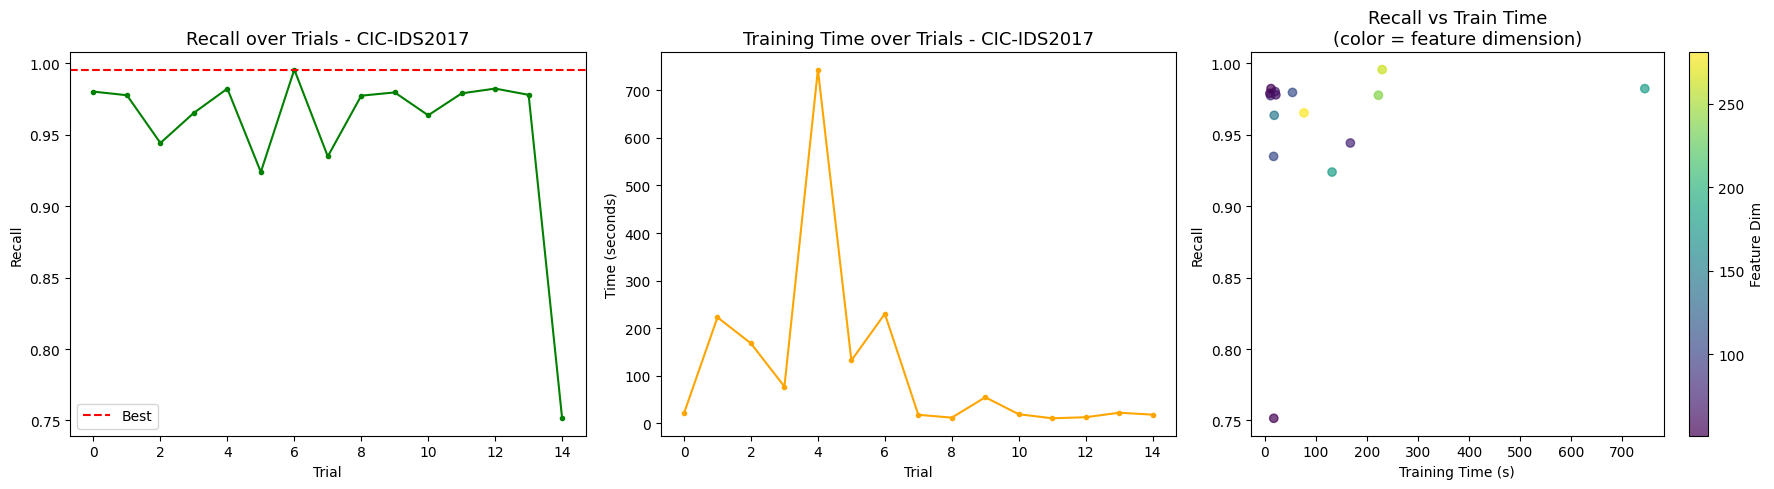

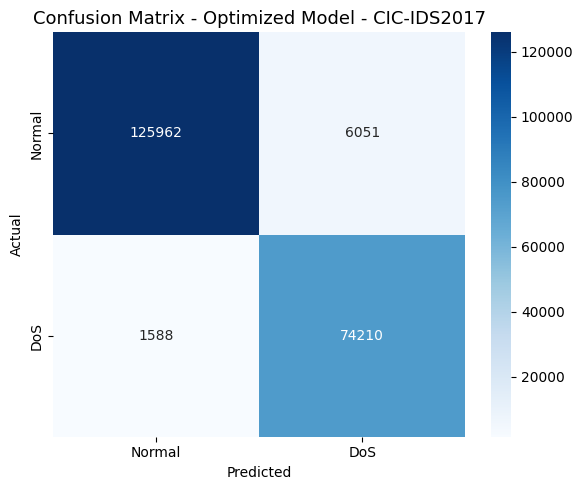

CIC-IDS2017 SUMMARY
Metric                 Baseline  Optimized
-------------------------------------------------------
Recall                   0.9331     0.9790
Precision                0.9662     0.9246
F1-Score                 0.9493     0.9511
Train Time (s)            62.79      11.23


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
# Plot optimization results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

trials_cic_df = study_cic.trials_dataframe()

axes[0].plot(trials_cic_df['user_attrs_recall'], color='green', marker='o', markersize=3)
axes[0].set_title('Recall over Trials - CIC-IDS2017', fontsize=13)
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Recall')
axes[0].axhline(y=trials_cic_df['user_attrs_recall'].max(),
                color='red', linestyle='--', label='Best')
axes[0].legend()

axes[1].plot(trials_cic_df['user_attrs_train_time'], color='orange', marker='o', markersize=3)
axes[1].set_title('Training Time over Trials - CIC-IDS2017', fontsize=13)
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('Time (seconds)')

scatter = axes[2].scatter(
    trials_cic_df['user_attrs_train_time'],
    trials_cic_df['user_attrs_recall'],
    c=trials_cic_df['user_attrs_final_dim'],
    cmap='viridis', alpha=0.7
)
axes[2].set_title('Recall vs Train Time\n(color = feature dimension)', fontsize=13)
axes[2].set_xlabel('Training Time (s)')
axes[2].set_ylabel('Recall')
plt.colorbar(scatter, ax=axes[2], label='Feature Dim')

plt.tight_layout()
plt.savefig('cic_optimization_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrix
best_cic_results = build_and_evaluate(
    X_train_cic_scaled, y_train_cic,
    X_test_cic_scaled,  y_test_cic,
    n_components=best_cic.params['n_components'],
    kernel_dim=best_cic.params['kernel_dim'],
    gamma=best_cic.params['gamma'],
    C=best_cic.params['C'],
    class_weight=best_cic.params['class_weight']
)

cm_cic = confusion_matrix(y_test_cic, best_cic_results['y_pred'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm_cic, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'DoS'],
            yticklabels=['Normal', 'DoS'])
plt.title('Confusion Matrix - Optimized Model - CIC-IDS2017', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('cic_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("=" * 55)
print("CIC-IDS2017 SUMMARY")
print("=" * 55)
print(f"{'Metric':<20} {'Baseline':>10} {'Optimized':>10}")
print("-" * 55)
print(f"{'Recall':<20} {results_cic['recall']:>10.4f} {best_cic_results['recall']:>10.4f}")
print(f"{'Precision':<20} {results_cic['precision']:>10.4f} {best_cic_results['precision']:>10.4f}")
print(f"{'F1-Score':<20} {results_cic['f1']:>10.4f} {best_cic_results['f1']:>10.4f}")
print(f"{'Train Time (s)':<20} {results_cic['train_time']:>10.2f} {best_cic_results['train_time']:>10.2f}")
print("=" * 55)

# Download summary
summary_cic = pd.DataFrame({
    'Metric': ['Recall', 'Precision', 'F1-Score', 'Train Time (s)',
               'PCA Components', 'Kernel Dimension'],
    'Baseline': [results_cic['recall'], results_cic['precision'],
                 results_cic['f1'], results_cic['train_time'], 20, 100],
    'Optimized': [best_cic_results['recall'], best_cic_results['precision'],
                  best_cic_results['f1'], best_cic_results['train_time'],
                  best_cic.params['n_components'], best_cic.params['kernel_dim']],
})

summary_cic.to_csv('cic_results_summary.csv', index=False)
from google.colab import files
files.download('cic_results_summary.csv')
files.download('cic_optimization_results.png')
files.download('cic_confusion_matrix.png')